In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report , root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
#for decision tree
from sklearn.tree import DecisionTreeRegressor , plot_tree
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("diamonds.csv")
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [4]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Unnamed: 0"]

0            1
1            2
2            3
3            4
4            5
         ...  
53935    53936
53936    53937
53937    53938
53938    53939
53939    53940
Name: Unnamed: 0, Length: 53940, dtype: int64

In [7]:
df.drop(columns=["Unnamed: 0"],inplace =True)

In [8]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


# Checking the unique values for object columns

In [9]:
for i in df.select_dtypes(object):
    print(df[i].nunique())
    print(df[i].value_counts())
    print("**********")

5
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
**********
7
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
**********
8
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64
**********


### Detecting Outliers

carat
upper fence is : 2.0
lower fence is : -0.5599999999999999


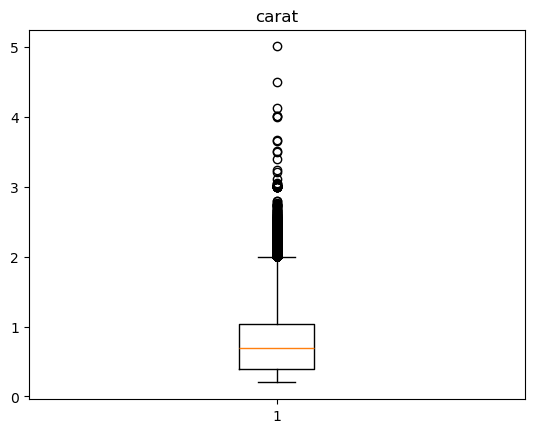

depth
upper fence is : 64.75
lower fence is : 58.75


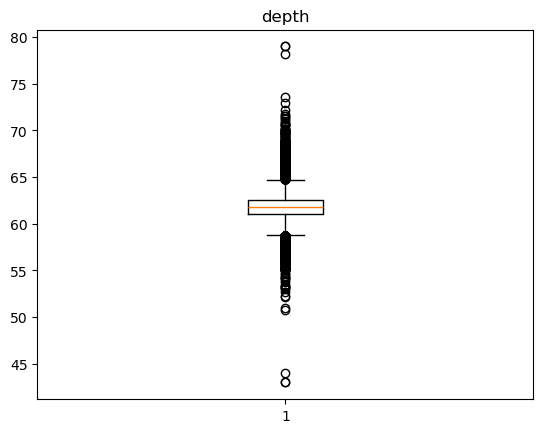

table
upper fence is : 63.5
lower fence is : 51.5


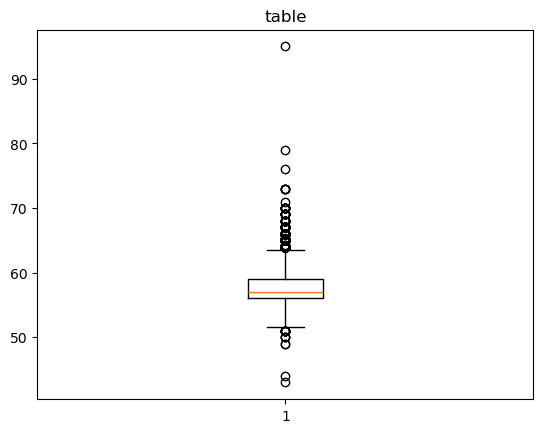

price
upper fence is : 11885.625
lower fence is : -5611.375


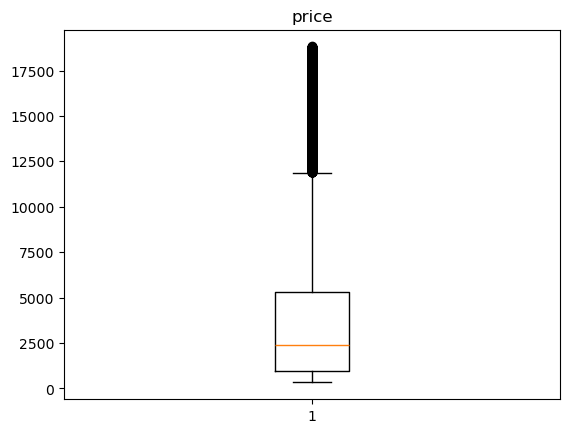

x
upper fence is : 9.285
lower fence is : 1.9649999999999999


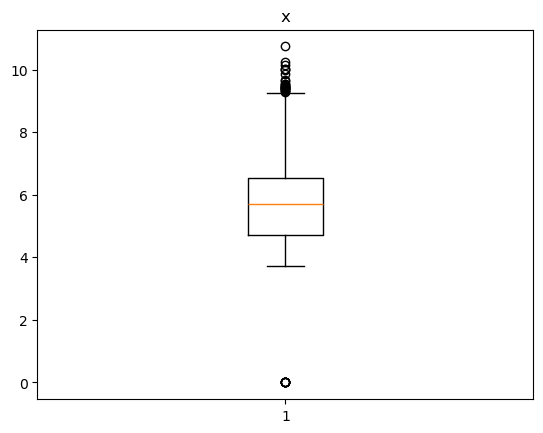

y
upper fence is : 9.27
lower fence is : 1.9899999999999993


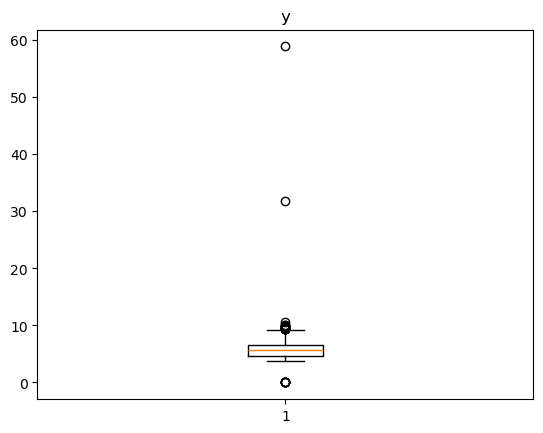

z
upper fence is : 5.734999999999999
lower fence is : 1.2150000000000003


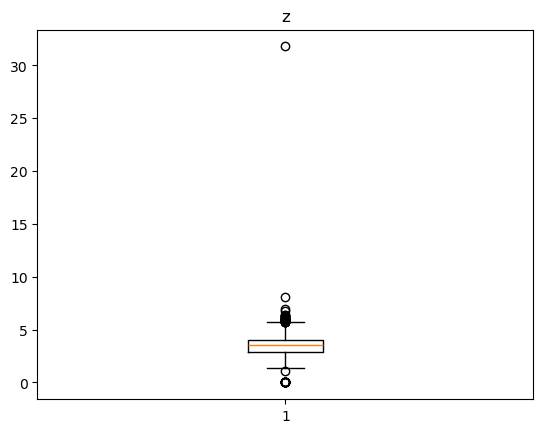

In [10]:
for i in df.select_dtypes([int,float]):
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lf = q1 - (1.5*iqr)
    uf = q3 + (1.5*iqr)
    print(i)
    print(f"upper fence is : {uf}")
    print(f"lower fence is : {lf}")
    plt.title(i)
    plt.boxplot(df[i])
    plt.show()

### Removing outliers

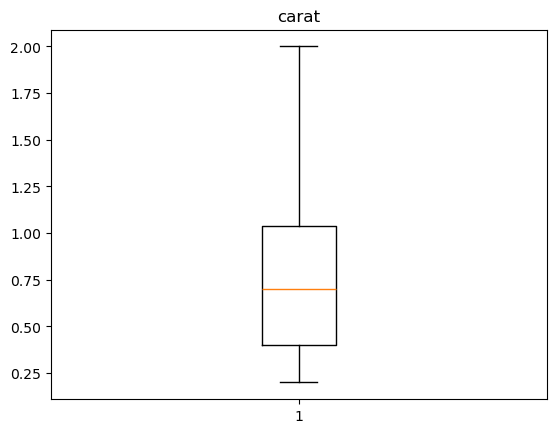

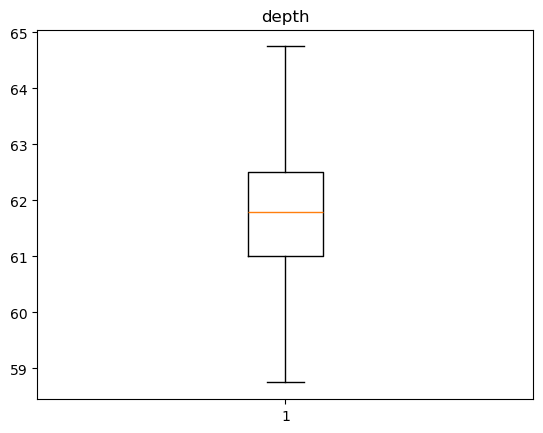

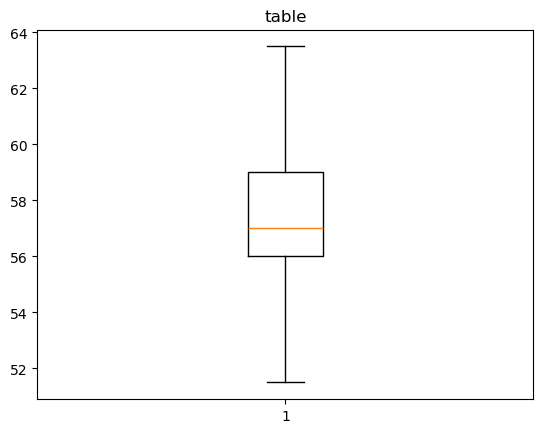

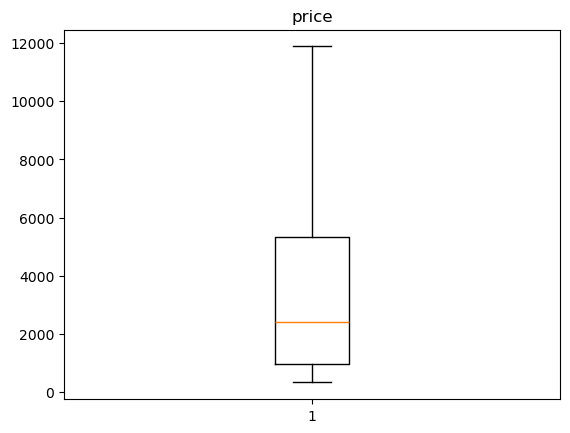

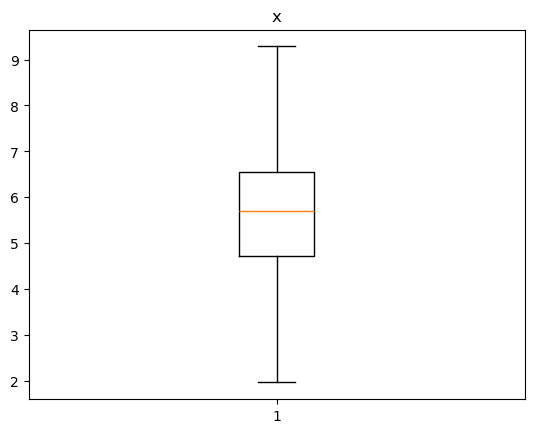

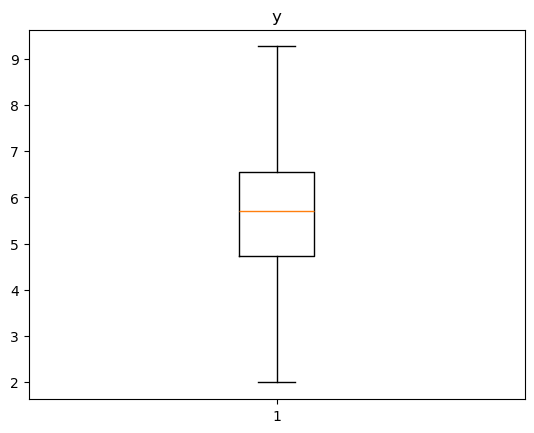

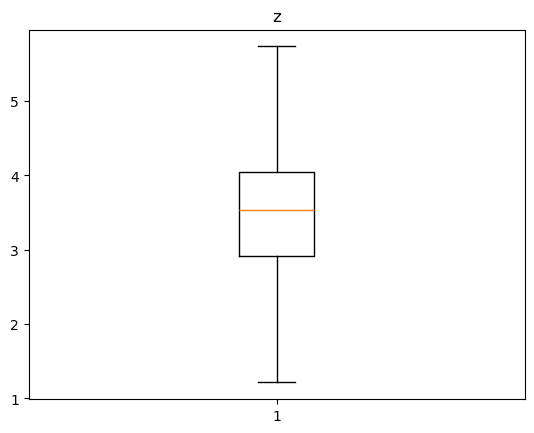

In [11]:
for i in df.select_dtypes([int,float]):
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lf = q1 - (1.5*iqr)
    uf = q3 + (1.5*iqr)
    df[i] = np.where(df[i] > uf, uf, df[i])
    df[i] = np.where(df[i] < lf, lf, df[i]) 
    plt.title(i)
    plt.boxplot(df[i])
    plt.show()

In [12]:
le = LabelEncoder()
for i in df.select_dtypes(object):
    df[i] = le.fit_transform(df[i])

In [13]:
df1 = pd.get_dummies(df, columns=["cut", "color","clarity"])
df1

,carat,depth,table,price,x,y,z,cut_0,cut_1,cut_2,...,color_5,color_6,clarity_0,clarity_1,clarity_2,clarity_3,clarity_4,clarity_5,clarity_6,clarity_7
0,0.23,61.50,55.0,326.0,3.95,3.98,2.43,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.80,61.0,326.0,3.89,3.84,2.31,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0.23,58.75,63.5,327.0,4.05,4.07,2.31,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.40,58.0,334.0,4.20,4.23,2.63,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.30,58.0,335.0,4.34,4.35,2.75,False,True,False,...,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.80,57.0,2757.0,5.75,5.76,3.50,False,False,True,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.10,55.0,2757.0,5.69,5.75,3.61,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.80,60.0,2757.0,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.00,58.0,2757.0,6.15,6.12,3.74,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53940 non-null  float64
 1   depth      53940 non-null  float64
 2   table      53940 non-null  float64
 3   price      53940 non-null  float64
 4   x          53940 non-null  float64
 5   y          53940 non-null  float64
 6   z          53940 non-null  float64
 7   cut_0      53940 non-null  bool   
 8   cut_1      53940 non-null  bool   
 9   cut_2      53940 non-null  bool   
 10  cut_3      53940 non-null  bool   
 11  cut_4      53940 non-null  bool   
 12  color_0    53940 non-null  bool   
 13  color_1    53940 non-null  bool   
 14  color_2    53940 non-null  bool   
 15  color_3    53940 non-null  bool   
 16  color_4    53940 non-null  bool   
 17  color_5    53940 non-null  bool   
 18  color_6    53940 non-null  bool   
 19  clarity_0  53940 non-null  bool   
 20  clarit

In [15]:
y = df1["price"]
x = df1.drop(columns="price")

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.3, random_state= 72)

In [17]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
print("R square of training model : ",model.score(x_train,y_train))
print("R square of testing model : ",model.score(x_test,y_test))

R square of training model :  0.9405800800329523
R square of testing model :  0.940609341501109


In [19]:
actual = y_train
pred = model.predict(x_train)
error = actual - pred

In [20]:
error

46396    164.643668
6074      48.575285
47434    353.032773
26668   -666.473430
46838   -746.310174
            ...    
2885    -632.691428
20325    458.285667
7242    -138.988614
5166      37.400140
12760   -313.338064
Name: price, Length: 37758, dtype: float64

In [21]:
MSE = np.mean(np.square(error))
print("MSE",MSE)
print("RMSE",np.sqrt(MSE))

MSE 692915.8389130054
RMSE 832.4156647450872


In [22]:
dt = DecisionTreeRegressor(random_state = 88,
                          max_depth = 12,
                          min_samples_split = 200,
                          min_samples_leaf = 5)
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,12
,min_samples_split,200
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,88
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
print("Training data score is : ",dt.score(x_train,y_train))
print("Testing data score is : ",dt.score(x_test,y_test))f

Training data score is :  0.9799632625201476
Testing data score is :  0.9780622510407874


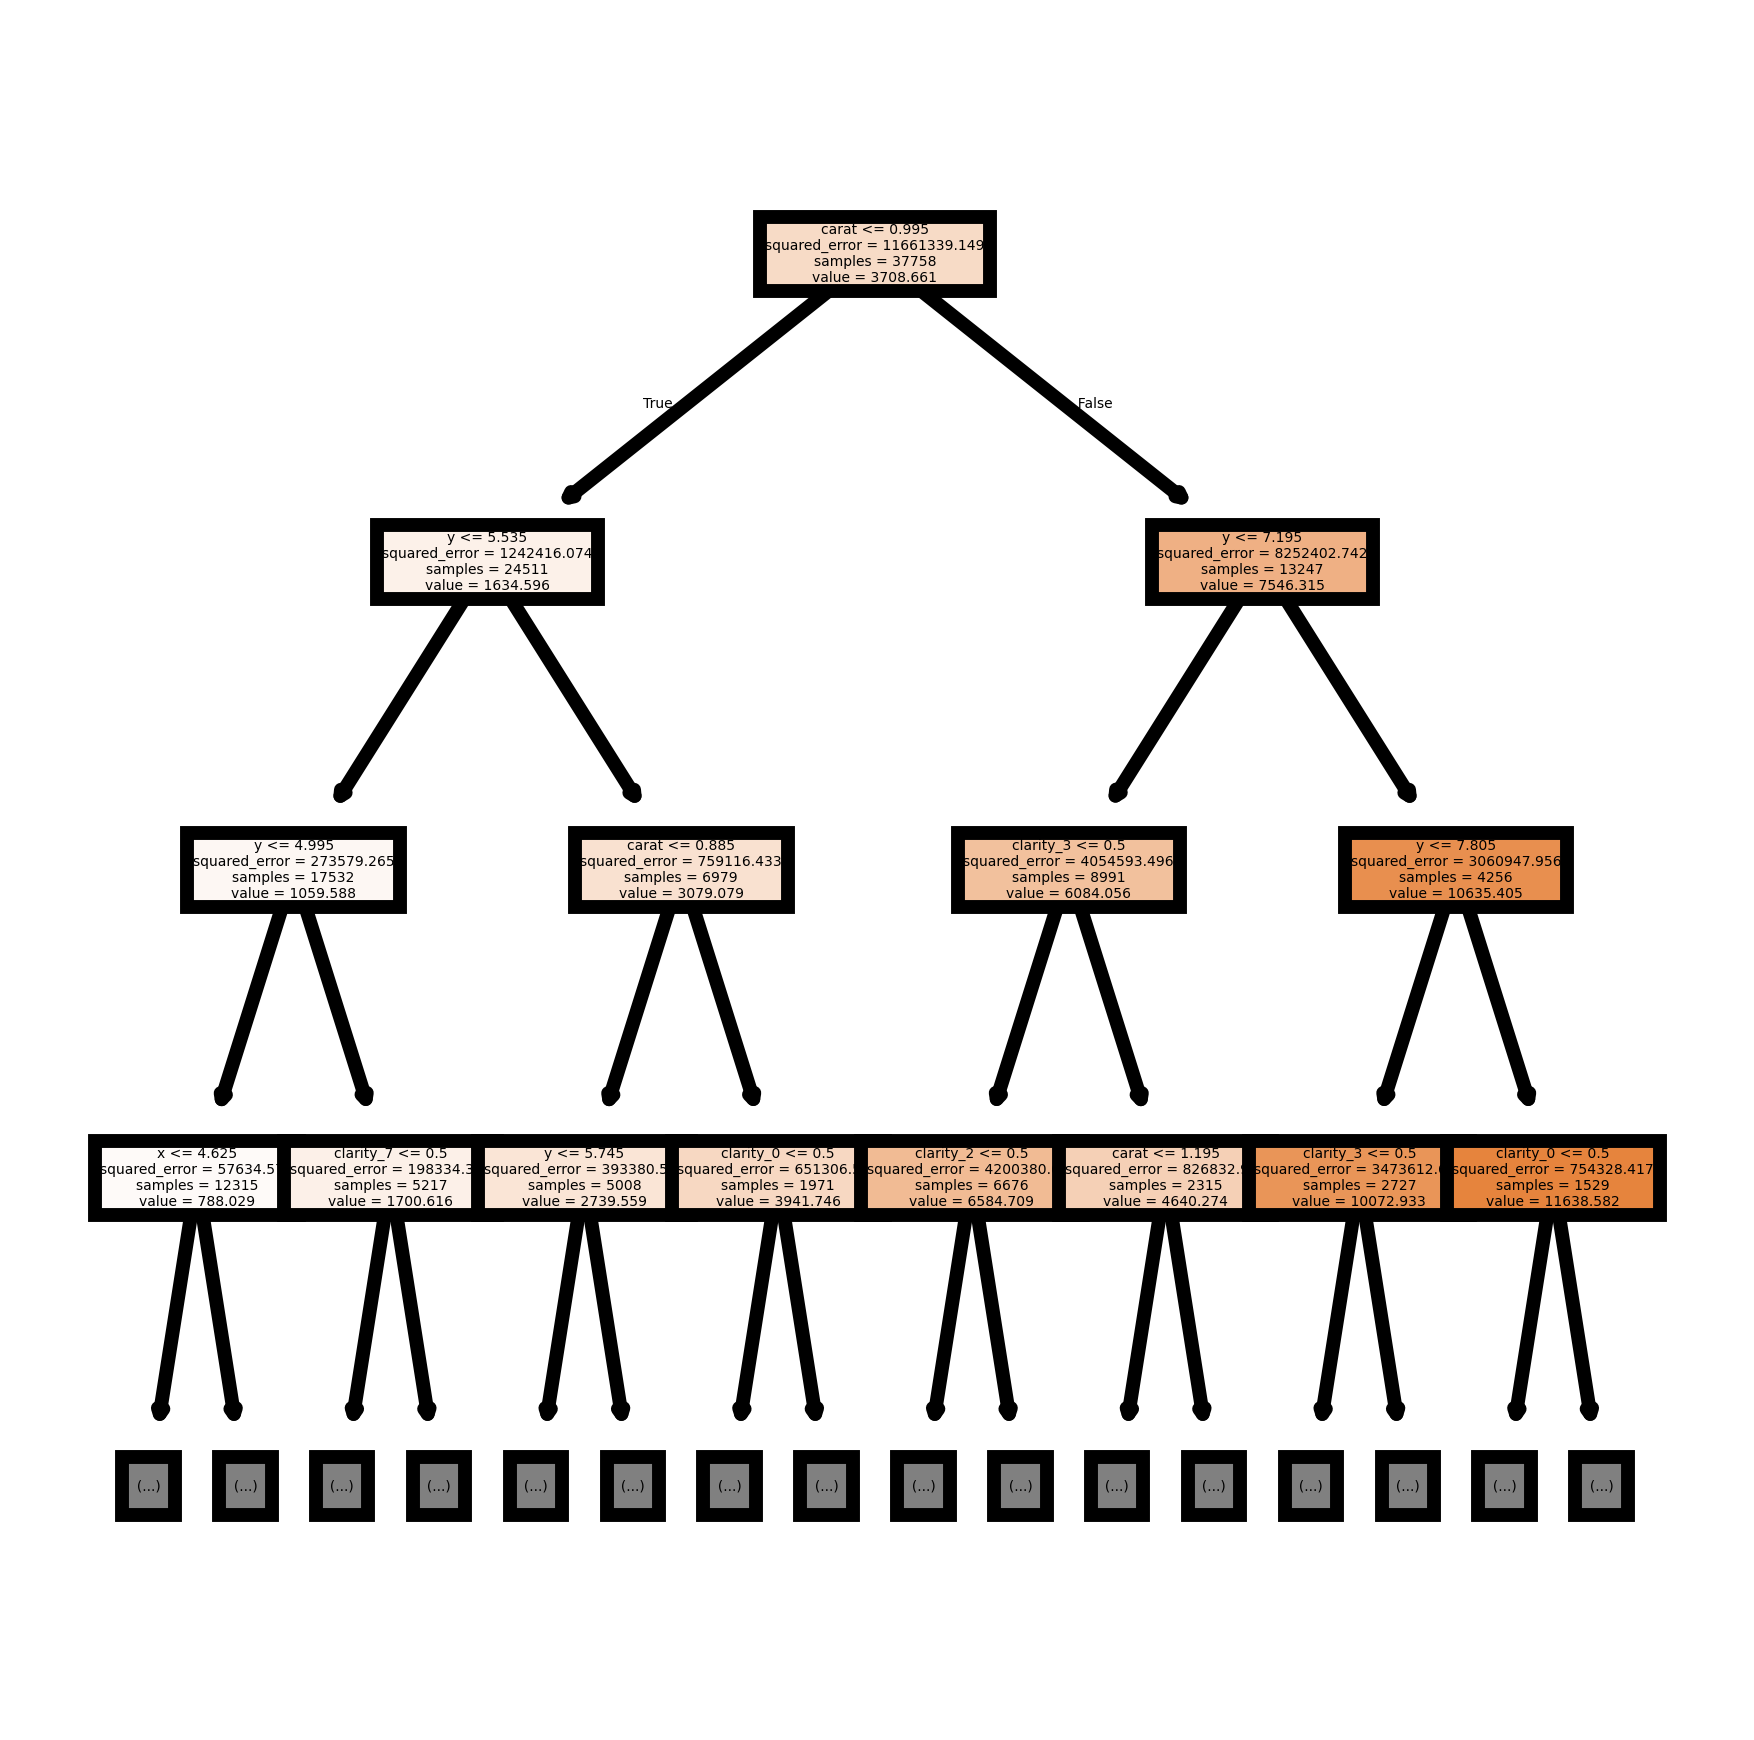

In [24]:
fig, axes = plt.subplots(figsize = (2,2),dpi = 1000)
plot_tree(dt, feature_names = x_train.columns, max_depth = 3, filled = True)
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [27]:
para = {
    "n_estimators" : [50,100,150,200,250,300],
    "max_depth" : [2,4,6],
    "min_samples_split" : [200,250]
}

rf = RandomForestRegressor(random_state = 72)
gs = GridSearchCV(rf, param_grid = para, verbose = 1, n_jobs = -1)
gs.fit(x_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,RandomForestR...ndom_state=72)
,param_grid,"{'max_depth': [2, 4, ...], 'min_samples_split': [200, 250], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


### The GridSearchCV gives the best parameters as : max_depth=6, min_samples_split=200, n_estimators=50,random_state=72

In [29]:
rf = RandomForestRegressor(max_depth=6, min_samples_split=200, n_estimators=50,random_state=72)
rf.fit(x_train,y_train)
print("Training data score is : ",rf.score(x_train,y_train))
print("Testing data score is : ",rf.score(x_test,y_test))

Training data score is :  0.9799632625201476
Testing data score is :  0.9780622510407874
